# **1. Perkenalan Dataset**
- **Nama:** Azzar Budiyanto
- **Email:** azzar.mr.zs@gmail.com
- **GitHub:** https://github.com/1999AZZAR

Dataset yang digunakan adalah **Heart Disease Dataset** dari UCI Machine Learning Repository (Cleveland version).

- **Sumber**: https://archive.ics.uci.edu/ml/datasets/Heart+Disease
- **Jumlah Data**: 303 sampel
- **Jumlah Fitur**: 13 fitur (campuran numerik dan kategorikal encoded)
- **Target**: Keberadaan penyakit jantung (0 = tidak ada, 1-4 = ada)
- **Tipe Masalah**: Klasifikasi Biner (diolah dari multikelas)

# **2. Import Library**

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print('Library berhasil diimpor.')

Library berhasil diimpor.


# **3. Memuat Dataset**

In [2]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
df = pd.read_csv('heart_disease_raw/heart_disease.csv', names=columns, na_values="?")

print(f'Total data: {len(df)}')
print(f'Jumlah kolom: {df.shape[1]}')
print('\n5 baris pertama:')
df.head()

Total data: 303
Jumlah kolom: 14

5 baris pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
print('Info Dataset:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
t

# **4. Exploratory Data Analysis (EDA)**

In [4]:
print('Statistik Deskriptif:')
df.describe()

Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


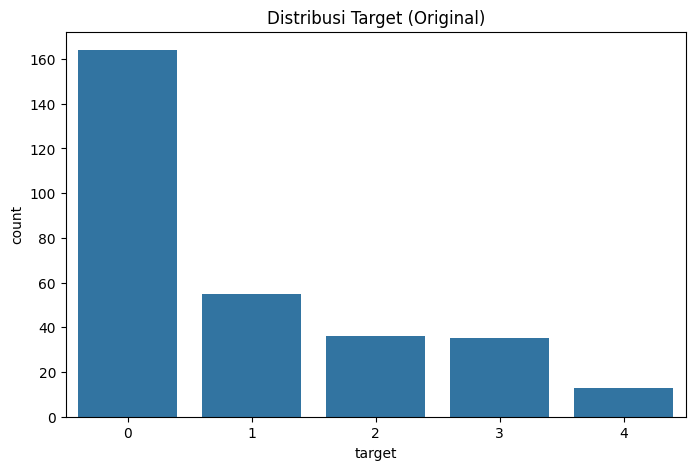

Value Counts Target:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df)
plt.title('Distribusi Target (Original)')
plt.show()

print('Value Counts Target:')
print(df['target'].value_counts())

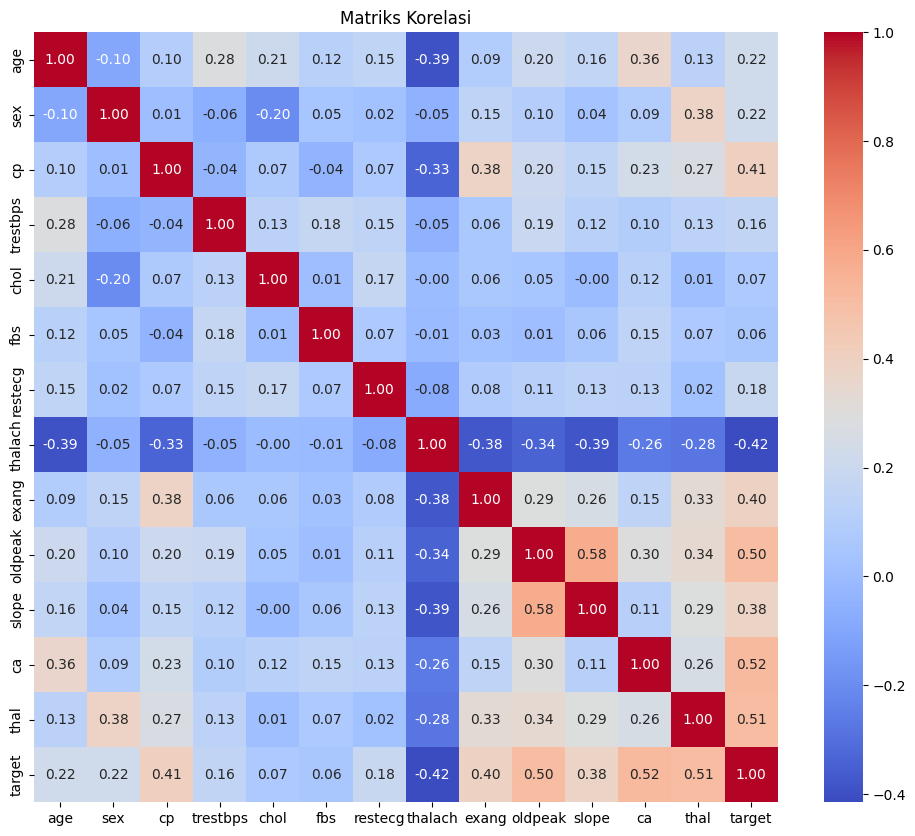

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()

# **5. Data Preprocessing**

In [7]:
# 1. Drop missing values
df = df.dropna()

# 2. Convert to binary classification
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f'Jumlah data setelah cleaning: {len(df)}')
print('Distribusi target baru:')
print(df['target'].value_counts())

Jumlah data setelah cleaning: 297
Distribusi target baru:
target
0    160
1    137
Name: count, dtype: int64


In [8]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train.shape[0]}')
print(f'Test set: {X_test.shape[0]}')

Train set: 237
Test set: 60


# **6. Pemodelan Awal**

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Akurasi: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Akurasi: 0.8667

Classification Report:


              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60

